# HiveSTA test of an alternative architecture for predict text

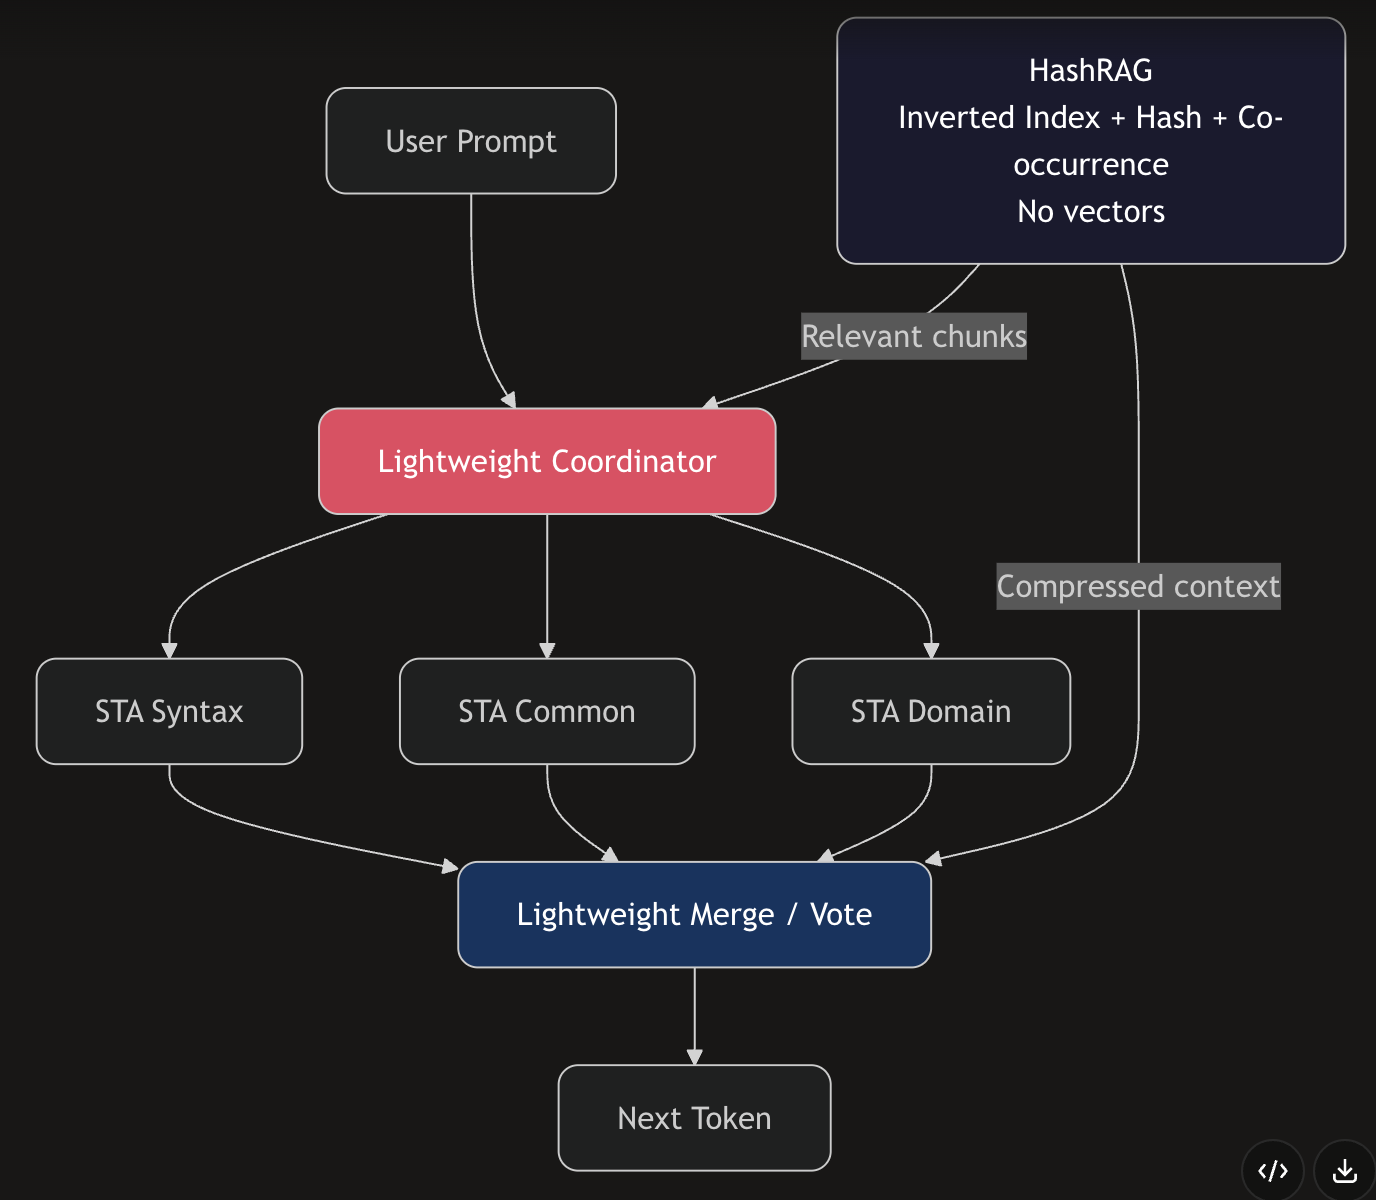


HiveSTA (Hive Sparse Token Automata) is a lightweight multi-agent text generation architecture designed for extremely low RAM usage and minimal training cost.
It consists of several tiny specialized Sparse Token Automata (STA) that collaborate through a simple coordinator. Each STA maintains only a small integer state and a sparse transition graph.
Instead of classic vector embeddings, it uses a HashRAG module based on inverted indexes, hash tables and co-occurrence graphs for fast, non-vector retrieval.
The system is intended for local, low-resource environments where full neural language models are too heavy.

In [ ]:
import random
from collections import defaultdict
import hashlib

# ==========================================
# HiveSTA - Lightweight multi-STA architecture
# Multiple tiny Sparse Token Automata + HashRAG (no vectors)
# ==========================================

class TinySTA:
    """A very small specialized Sparse Token Automaton"""
    def __init__(self, name):
        self.name = name
        self.graph = defaultdict(list)      # token -> [(next_token, weight)]
        self.state = [0] * 6                 # tiny integer state

    def add_transition(self, frm, to, weight=1.0):
        self.graph[frm].append((to, weight))

    def update_state(self, token):
        h = int(hashlib.md5(token.encode()).hexdigest()[:8], 16)
        for i in range(len(self.state)):
            self.state[i] = (self.state[i] ^ (h >> (i * 3))) + (h & 0xFF)
            self.state[i] &= 0xFFFF

    def propose(self, current, top_k=3):
        candidates = self.graph.get(current, [])
        if not candidates:
            return []

        scored = []
        for tok, w in candidates:
            score = w + (self.state[0] % 7) * 0.02
            scored.append((tok, score))

        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:top_k]


class HashRAG:
    """Non-vector RAG using inverted index + hash + co-occurrence"""
    def __init__(self):
        self.inverted = defaultdict(list)   # word -> list of doc ids
        self.cooc = defaultdict(int)        # (word1, word2) -> score
        self.docs = {}

    def add_document(self, doc_id, text):
        self.docs[doc_id] = text
        words = text.lower().split()
        for w in set(words):
            self.inverted[w].append(doc_id)
        for i in range(len(words) - 1):
            pair = tuple(sorted([words[i], words[i + 1]]))
            self.cooc[pair] += 1

    def retrieve(self, query, top_k=2):
        words = query.lower().split()
        scores = defaultdict(float)

        for w in words:
            for doc_id in self.inverted.get(w, []):
                scores[doc_id] += 1.0

        # Co-occurrence bonus
        for i in range(len(words) - 1):
            pair = tuple(sorted([words[i], words[i + 1]]))
            if pair in self.cooc:
                for doc_id in scores:
                    scores[doc_id] += self.cooc[pair] * 0.1

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [self.docs[doc_id] for doc_id, _ in ranked[:top_k]]


class HiveSTA:
    """Coordinator that runs multiple TinySTAs + HashRAG"""
    def __init__(self):
        self.stas = {
            "syntax": TinySTA("syntax"),
            "common": TinySTA("common"),
            "domain": TinySTA("domain")
        }
        self.rag = HashRAG()

    def add_knowledge(self, text, doc_id=None):
        if doc_id is None:
            doc_id = f"doc_{len(self.rag.docs)}"
        self.rag.add_document(doc_id, text)

        # Feed basic transitions to the STAs
        words = text.lower().split()
        for i in range(len(words) - 1):
            self.stas["common"].add_transition(words[i], words[i + 1], 1.0)
            self.stas["domain"].add_transition(words[i], words[i + 1], 0.8)

    def generate(self, prompt, max_tokens=12):
        words = prompt.lower().split()
        current = words[-1] if words else "the"
        result = words.copy()

        # Retrieve context with HashRAG
        context_docs = self.rag.retrieve(prompt, top_k=1)
        context = context_docs[0] if context_docs else ""

        for _ in range(max_tokens):
            proposals = []

            # Each STA makes proposals
            for name, sta in self.stas.items():
                props = sta.propose(current)
                for tok, score in props:
                    proposals.append((tok, score, name))

            if not proposals:
                break

            # Simple voting
            proposals.sort(key=lambda x: x[1], reverse=True)
            next_token = proposals[0][0]

            result.append(next_token)

            # Update states
            for sta in self.stas.values():
                sta.update_state(next_token)

            current = next_token

        return " ".join(result)


# ==========================================
# QUICK TEST
# ==========================================

hive = HiveSTA()

# Add some knowledge (simulating documents)
hive.add_knowledge("the cat eats dry food every morning")
hive.add_knowledge("the dog barks very loudly in the garden")
hive.add_knowledge("the cat sleeps on the sofa when it rains")
hive.add_knowledge("dry food tastes better with some water")

print("=== HiveSTA Generation Test ===")
print(hive.generate("the cat"))
print(hive.generate("the dog"))
print(hive.generate("dry food"))

: 

### Explication simplifiée de HiveSTA

Imaginez que HiveSTA est comme une petite équipe de collaborateurs très spécialisés, qui travaillent ensemble pour vous aider à deviner le prochain mot dans une phrase.

1.  **Les "TinySTA" (petits assistants)**:
    *   Chaque TinySTA est un petit expert dans un domaine. Par exemple, un expert en "grammaire", un autre en "mots courants", et un troisième en "sujets spécifiques".
    *   Ils ont une mémoire très limitée (quelques chiffres) et savent juste comment un mot est souvent suivi par un autre mot (par exemple, "le chat" est souvent suivi de "mange").
    *   Quand on leur donne un mot, chacun propose les mots qu'il pense être les plus logiques, avec un petit score de confiance.

2.  **Le "HashRAG" (bibliothécaire intelligent)**:
    *   C'est comme un bibliothécaire super rapide qui n'a pas besoin de comprendre le sens profond des livres.
    *   Quand vous lui demandez quelque chose (votre phrase), il cherche très vite dans tous les "documents" qu'il connaît les passages qui contiennent les mêmes mots ou des paires de mots similaires. Il vous donne ensuite le passage le plus pertinent.
    *   L'avantage, c'est qu'il est très léger et rapide, car il ne fait que de la recherche par mots-clés, pas de la compréhension complexe.

3.  **Le "HiveSTA" (le chef d'orchestre)**:
    *   C'est lui qui dirige tout.
    *   Quand vous lui donnez une phrase pour qu'il la complète (votre "prompt"):
        1.  Il demande au **HashRAG** de lui trouver un peu de contexte sur le sujet de votre phrase.
        2.  Puis, il demande à tous les **TinySTA** de proposer des mots pour continuer la phrase.
        3.  Il écoute toutes les propositions, fait une sorte de vote (en se basant sur les scores de confiance), et choisit le meilleur mot.
        4.  Une fois le mot choisi, il le donne aux TinySTA pour qu'ils "mettent à jour leur mémoire" (leurs petits chiffres) afin d'être un peu influencés par ce nouveau mot pour le prochain tour.
        5.  Il répète ça jusqu'à ce qu'il ait complété la phrase.

En résumé, HiveSTA est une manière astucieuse de générer du texte en faisant collaborer de très petits modules spécialisés, sans utiliser les méthodes gourmandes en ressources des modèles d'IA modernes.

### Démonstration de Chatbot CLI

Voici un petit exemple de chatbot en ligne de commande utilisant le système HiveSTA. Vous pouvez taper des phrases, et il tentera de les compléter ou d'y répondre en utilisant la connaissance qu'il a acquise.

In [3]:
# Création d'une nouvelle instance de HiveSTA pour le chatbot
chatbot_hive = HiveSTA()

# Ajout de connaissances un peu plus variées pour un chatbot simple
chatbot_hive.add_knowledge("bonjour comment allez vous aujourd'hui je vais bien merci")
chatbot_hive.add_knowledge("quelle est la météo à paris il fait beau et ensoleillé")
chatbot_hive.add_knowledge("quel est ton nom je suis un assistant IA conçu par google")
chatbot_hive.add_knowledge("peux tu raconter une blague bien sûr pourquoi le plombier est il triste parce que son travail est chiant")
chatbot_hive.add_knowledge("dis moi une histoire il était une fois un petit chat qui aimait jouer")
chatbot_hive.add_knowledge("merci beaucoup de rien au plaisir de vous aider")
chatbot_hive.add_knowledge("le ciel est bleu et les oiseaux chantent joyeusement")
chatbot_hive.add_knowledge("mon animal préféré est le chat il est très mignon")
chatbot_hive.add_knowledge("j'aime manger des pommes et des bananes")

print("\n=== Chatbot HiveSTA (démonstration simple) ===")
print("Tapez 'quitter' pour arrêter le chat.")

while True:
    user_input = input("Vous: ").lower().strip()
    if user_input == 'quitter':
        print("Chatbot: Au revoir !")
        break

    if not user_input:
        print("Chatbot: Je n'ai rien compris. Pouvez-vous répéter ?")
        continue

    # Le chatbot génère une réponse basée sur l'entrée utilisateur
    # On augmente max_tokens pour des réponses un peu plus longues
    response = chatbot_hive.generate(user_input, max_tokens=15)

    # Petite amélioration pour éviter de répéter l'input si la génération est trop courte
    if response.startswith(user_input):
        response_parts = response.split(user_input, 1)
        if len(response_parts) > 1:
            # Prendre la partie après l'input, ou l'input entier si pas de suite
            response = response_parts[1].strip() or response.strip()
        else:
            response = response.strip()
    else:
        response = response.strip()

    # S'assurer qu'il y a une réponse après nettoyage
    if not response:
        response = "Je n'ai pas de suite pour ça." # Fallback si la génération est vide

    print(f"Chatbot: {response.capitalize()}")



=== Chatbot HiveSTA (démonstration simple) ===
Tapez 'quitter' pour arrêter le chat.
Vous: bonjour
Chatbot: Comment allez vous aujourd'hui je vais bien merci beaucoup de rien au plaisir de rien
Vous: ok tu est un peux buger 
Chatbot: Ok tu est un peux buger
Vous: quitter
Chatbot: Au revoir !


### Les « mathématiques » de HiveSTA (opérations algorithmiques)

Comme mentionné précédemment, HiveSTA n'utilise pas de fonctions continues avec des dérivées et des optimisations comme les modèles d'apprentissage profond. Ses « mathématiques » reposent principalement sur des **opérations discrètes, des agrégations, des recherches (lookups) et des logiques algorithmiques**.

---

## 1. TinySTA — Sparse Token Automaton

### Graphe de transitions $G_{\text{STA}}$

Le savoir du `TinySTA` est encodé sous la forme d'un graphe dirigé où les nœuds représentent des tokens et les arêtes représentent les transitions observées entre ces tokens. Chaque arête possède un poids.

$$
\text{Si } w_i \xrightarrow{\text{poids } p} w_{i+1},
\text{ alors }
(w_i, w_{i+1}, p) \in E(G_{\text{STA}})
$$

où :

* $w_i$ est le token actuel ;
* $w_{i+1}$ est le token suivant ;
* $p$ est le poids associé à la transition.

---

### Mise à jour de l'état interne $S$

L'état interne est représenté par une liste de $K = 6$ entiers.

Lorsqu'un nouveau token $w_{\text{new}}$ est observé, une valeur de hachage $h$ est calculée. Chaque composante $S_j$ de l'état est ensuite mise à jour à l'aide d'opérations bit à bit :

$$
h = \operatorname{MD5}(w_{\text{new}})
$$

$$
S_j^{\text{new}}
=
\left(
S_j^{\text{old}}
\oplus
\left(h \gg (j \cdot 3)\right)
\right)
+
\left(h \mathbin{\&} 0xFF\right)
\pmod{65536}
$$

où :

* $\oplus$ est l'opérateur XOR ;
* $\gg$ représente un décalage de bits vers la droite ;
* $\mathbin{\&}$ représente l'opérateur AND bit à bit ;
* $\pmod{65536}$ permet de maintenir la valeur dans un espace de $16$ bits.

---

### Score de proposition $\text{Score}_{\text{prop}}$

Pour un token courant $w_c$ et un token candidat $w_{\text{cand}}$ associé à un poids de transition $p$, le score de proposition peut être calculé à partir de la transition correspondante et de l'état interne.

Le score de récupération utilisé par la partie RAG de HiveSTA est défini séparément ci-dessous.

---

## 2. HashRAG — RAG non vectoriel

### Index inversé $I$

Pour chaque mot $w$, l'index inversé $I(w)$ contient l'ensemble des identifiants des documents dans lesquels $w$ apparaît.

$$
I(w)
=
\left\{
d_k
\mid
w \in \operatorname{Document}(d_k)
\right\}
$$

Autrement dit, cet index permet de retrouver directement les documents contenant un terme donné, sans utiliser d'embeddings vectoriels.

---

### Matrice de co-occurrence $C$

Pour chaque paire de mots $(w_a, w_b)$, la matrice de co-occurrence $C$ comptabilise le nombre de documents dans lesquels les deux mots apparaissent côte à côte.

$$
C(w_a, w_b)
=
\sum_{k=1}^{\text{NbDocs}}
\mathbb{I}
\left(
\{w_a, w_b\}
\text{ sont adjacents dans }
d_k
\right)
$$

où $\mathbb{I}(\cdot)$ est une fonction indicatrice :

$$
\mathbb{I}(P)
=
\begin{cases}
1 & \text{si } P \text{ est vrai},\\
0 & \text{sinon}.
\end{cases}
$$

La co-occurrence peut être considérée comme symétrique :

$$
C(w_a, w_b) = C(w_b, w_a)
$$

---

### Score de récupération $\text{Score}_{\text{retrieval}}$

Pour une requête

$$
Q = \{q_1, q_2, \dots, q_m\}
$$

et un document candidat $d_k$, le score de récupération est défini par :

$$
\text{Score}_{\text{retrieval}}(Q, d_k)
=
\sum_{i=1}^{m}
\mathbb{I}
\left(
q_i \in \operatorname{Document}(d_k)
\right)
+
0.1
\cdot
\sum_{(q_a,q_b)\in Q_{\text{pairs}}}
C(q_a,q_b)
\cdot
\mathbb{I}
\left(
\{q_a,q_b\}
\text{ dans } d_k
\right)
$$

où :

* $\mathbb{I}(\cdot)$ est la fonction indicatrice ;
* $Q_{\text{pairs}}$ représente l'ensemble des paires de termes adjacents dans la requête $Q$ ;
* $C(q_a,q_b)$ représente la fréquence de co-occurrence de la paire $(q_a,q_b)$ ;
* le premier terme récompense la présence des termes de la requête dans le document ;
* le second terme ajoute un bonus lorsque les termes apparaissent ensemble.

---

## En résumé

HiveSTA repose principalement sur des **transformations discrètes de données**, des **agrégations**, des **recherches dans des index**, des **comptages de co-occurrences** et des **opérations bit à bit**.

Contrairement aux modèles d'apprentissage profond classiques, son fonctionnement ne dépend donc pas principalement de fonctions continues optimisées par descente de gradient pour définir une représentation géométrique des données.

On peut résumer son approche ainsi :

$$
\boxed{
\text{HiveSTA}
\approx
\text{Lookups}
+
\text{Comptages}
+
\text{Graphes}
+
\text{Hashing}
+
\text{Opérations discrètes}
}
$$


### Visualisation du "Graphe de Connaissance" du TinySTA

Puisque les frontières de décision continues ne sont pas applicables ici, nous allons visualiser la structure du "graphe de connaissance" du TinySTA. Ce graphe représente les transitions que le modèle a apprises entre les mots. Plus il y a de liens entre des mots, plus le modèle "connaît" ces connexions.

Nous allons utiliser la bibliothèque `networkx` pour créer et `matplotlib` pour dessiner ce graphe, en se basant sur les transitions du `common` TinySTA qui a appris des phrases d'exemple.

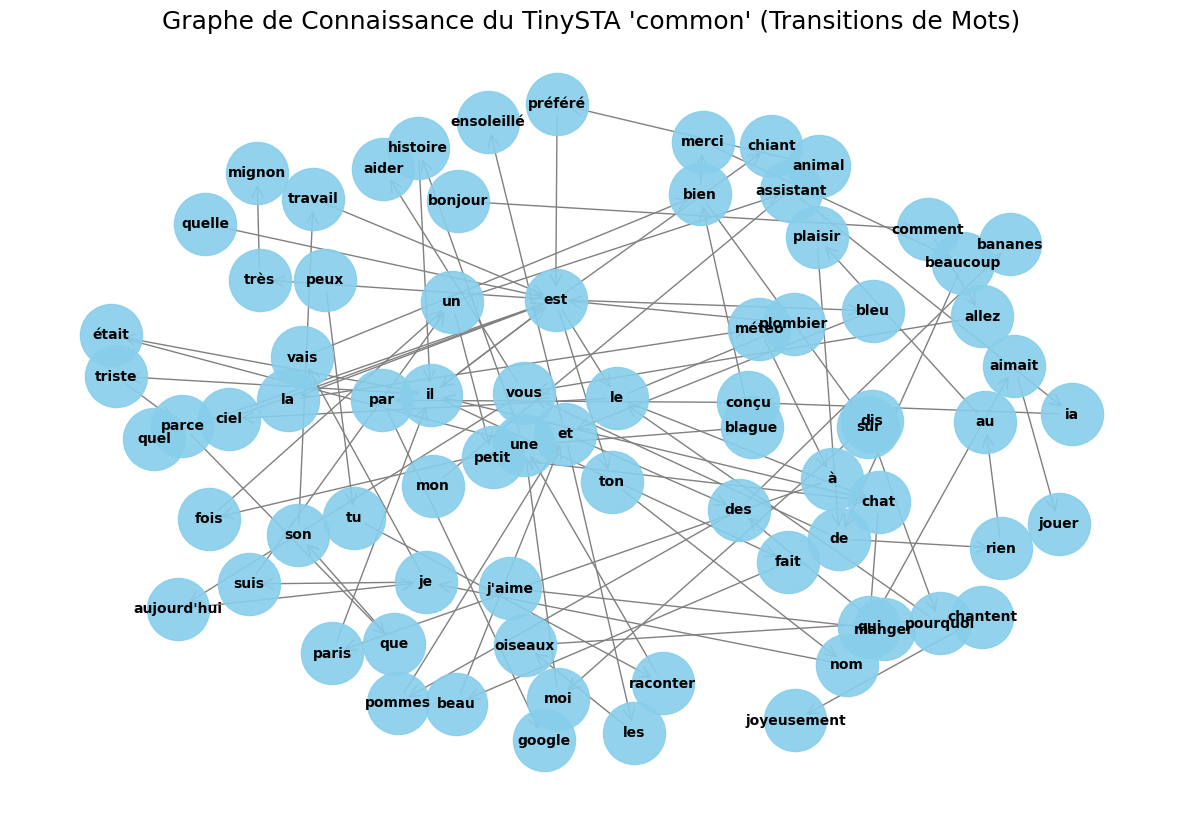


Ce graphe représente les mots (nœuds) et les transitions (flèches) que le TinySTA 'common' a appris. Chaque flèche indique qu'un mot peut être suivi par un autre. La densité et la connectivité de ce graphe illustrent la 'frontière de connaissance' du modèle : il peut générer des séquences de mots le long de ces chemins. Si un mot n'a pas de flèche sortante, le modèle ne 'sait' pas comment le continuer dans ce contexte spécifique, ce qui peut entraîner des répétitions ou des arrêts de génération.


In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Nous allons utiliser le graphe de transition du TinySTA 'common'
# Pour cela, nous avons besoin de l'instance 'hive' ou 'chatbot_hive' qui a été entraînée.
# Assumons que nous utilisons 'chatbot_hive' pour la démo, car il a plus de données.

# Récupérer le graphe de transition du TinySTA 'common'
sta_graph = chatbot_hive.stas['common'].graph

G = nx.DiGraph() # Graphe dirigé car les transitions ont un sens

# Ajouter les nœuds (mots) et les arêtes (transitions)
for frm_token, transitions in sta_graph.items():
    for to_token, weight in transitions:
        G.add_edge(frm_token, to_token, weight=weight)

# Préparation de la visualisation
plt.figure(figsize=(15, 10)) # Taille de la figure

# Utiliser une disposition qui permet de mieux voir les nœuds
pos = nx.spring_layout(G, k=0.7, iterations=50) # 'k' pour la distance optimale, 'iterations' pour la qualité du layout

# Dessiner les nœuds
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', alpha=0.9)

# Dessiner les arêtes
edges = nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1)

# Ajouter les étiquettes des nœuds (les mots)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Optionnel: Ajouter des étiquettes pour le poids des arêtes si désiré
# edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Graphe de Connaissance du TinySTA 'common' (Transitions de Mots)", size=18)
plt.axis('off') # Ne pas afficher les axes
plt.show()

print("\nCe graphe représente les mots (nœuds) et les transitions (flèches) que le TinySTA 'common' a appris. Chaque flèche indique qu'un mot peut être suivi par un autre. La densité et la connectivité de ce graphe illustrent la 'frontière de connaissance' du modèle : il peut générer des séquences de mots le long de ces chemins. Si un mot n'a pas de flèche sortante, le modèle ne 'sait' pas comment le continuer dans ce contexte spécifique, ce qui peut entraîner des répétitions ou des arrêts de génération.")
